## Data Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ai_job_dataset.csv')

In [3]:
df.shape

(15000, 19)

In [4]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [5]:
#display basic statistics
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [6]:
#check for missing values
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

## Exploratory Data Analysis

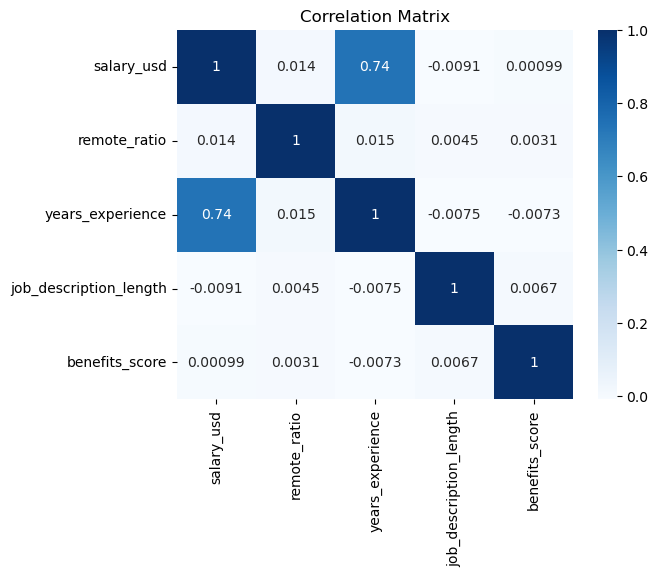

In [132]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap = 'Blues')
plt.title("Correlation Matrix")
plt.show()

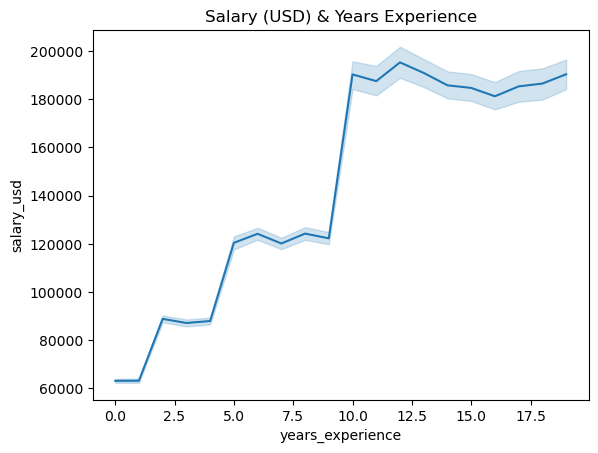

In [137]:
sns.lineplot(data=df, y='salary_usd', x='years_experience')
plt.title('Salary (USD) & Years Experience')

plt.show()

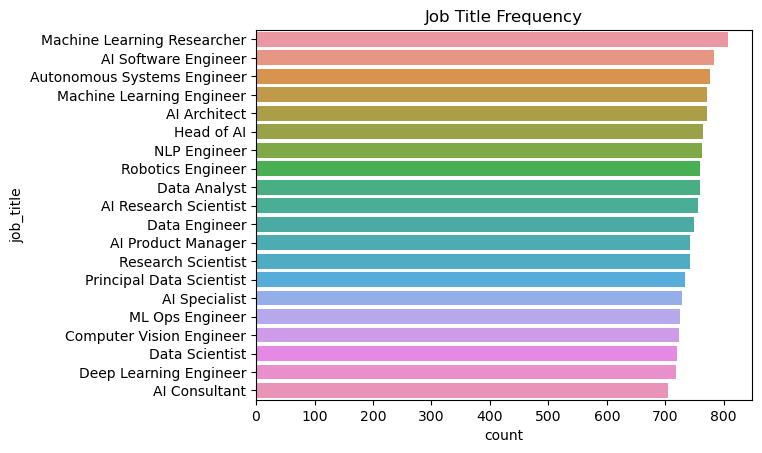

In [15]:
sns.countplot(df, y="job_title", order=df['job_title'].value_counts().index)
plt.title("Job Title Frequency")
plt.show()

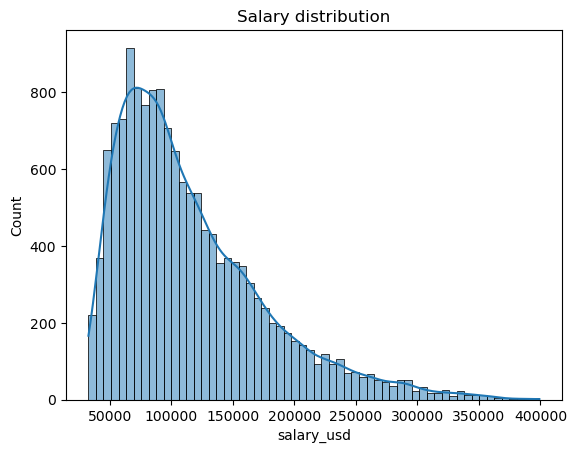

In [20]:
plt.title('Salary distribution')
sns.histplot(df['salary_usd'],kde=True)
plt.show()

In [37]:
# Funtion to sort the plots in descending way
def categories_desc_order(df,categories,values):
    cat_mean = df.groupby(categories)[values].mean()
    cat_desc = cat_mean.sort_values(ascending=False)
    return cat_desc.index

### Highest paying jobs

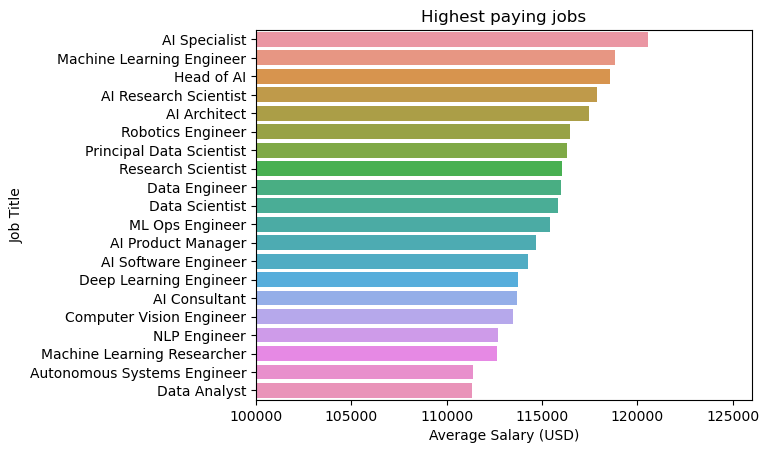

In [115]:
order = categories_desc_order(df,'job_title','salary_usd')
plt.xlim(100000, 126000)
plt.title('Highest paying jobs')
sns.barplot(x=df["salary_usd"],y=df["job_title"], order=order, errorbar=None)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")
plt.show()

### Highest paying countries

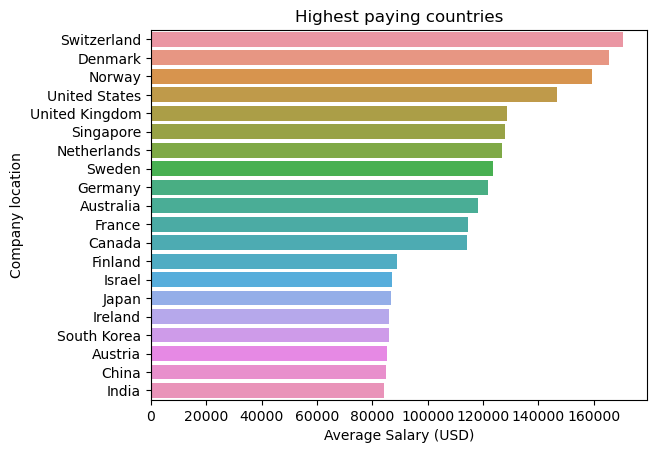

In [116]:
order = categories_desc_order(df,'company_location','salary_usd')
plt.title('Highest paying countries')
sns.barplot(data=df,x='salary_usd',y='company_location',order=order, errorbar = None)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company location")
plt.show()

### Highest paying industries

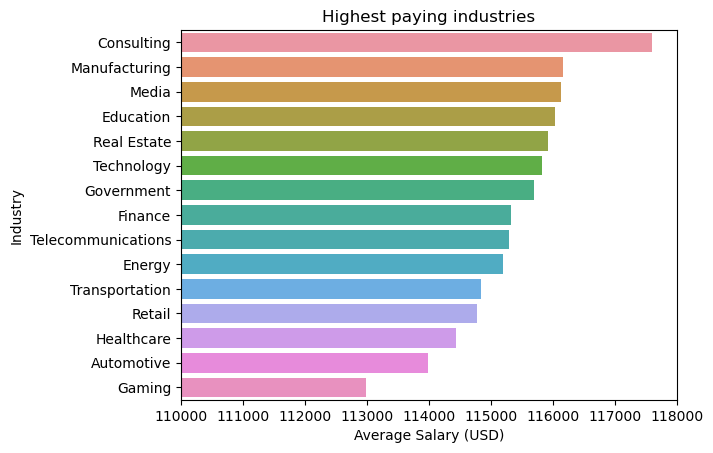

In [117]:
order = categories_desc_order(df,'industry','salary_usd')
plt.xlim(110000, 118000)
plt.title('Highest paying industries')
sns.barplot(data=df,x='salary_usd',y='industry',order=order, errorbar=None)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Industry")
plt.show()

### Highest paying companies

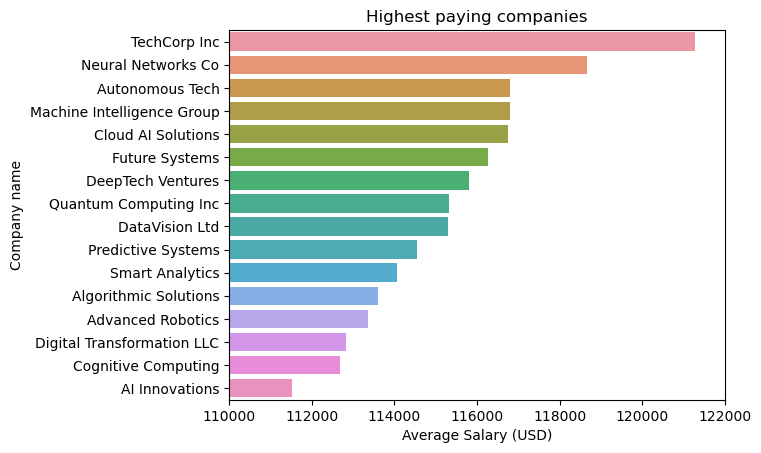

In [118]:
order = categories_desc_order(df,'company_name','salary_usd')
plt.xlim(110000, 122000)
plt.title('Highest paying companies')
sns.barplot(data=df,x='salary_usd',y='company_name',order=order, errorbar=None)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company name")
plt.show()

In [113]:
skill_list = df['required_skills'].str.split(',')
skills = [val.strip() for l in skill_list for val in l]
count = pd.Series(skills).value_counts()

### Most required skills

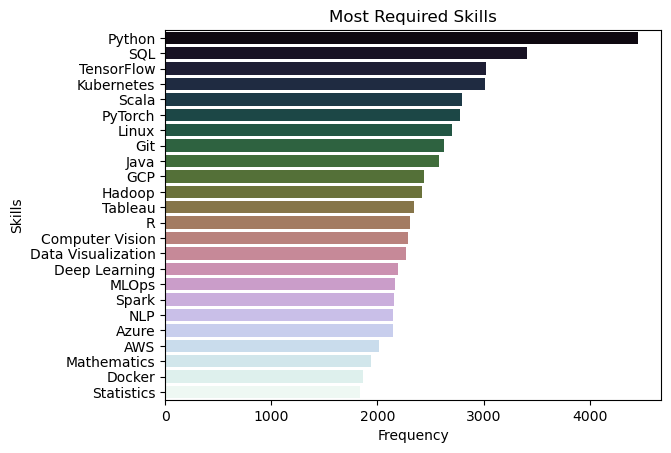

In [114]:
sns.countplot(y=skills, order = count.index, palette="cubehelix")
plt.title('Most Required Skills')
plt.ylabel('Skills')
plt.xlabel('Frequency')
plt.show()

### Education required

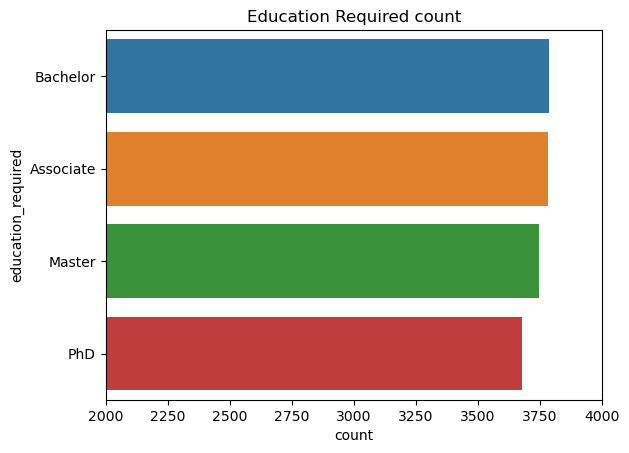

In [75]:
plt.xlim(2000, 4000)
sns.countplot(df, y='education_required', order = df['education_required'].value_counts().index)
plt.title('Education Required count')
plt.show()

### Average Salary by Education Level

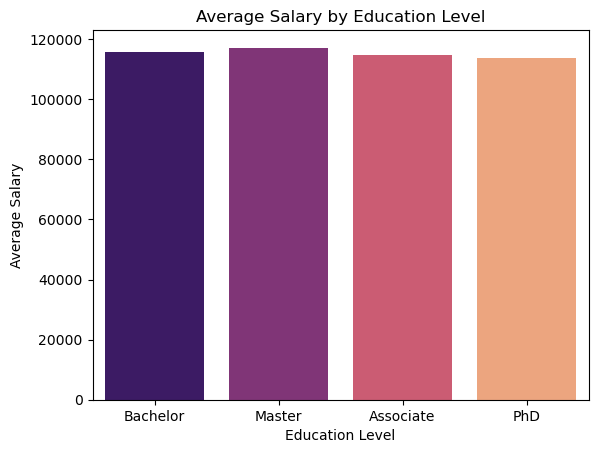

In [112]:
sns.barplot(x='education_required', y='salary_usd', data=df, estimator='mean', palette="magma", errorbar = None)
plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary")
plt.show()


### Salary by Experience Level

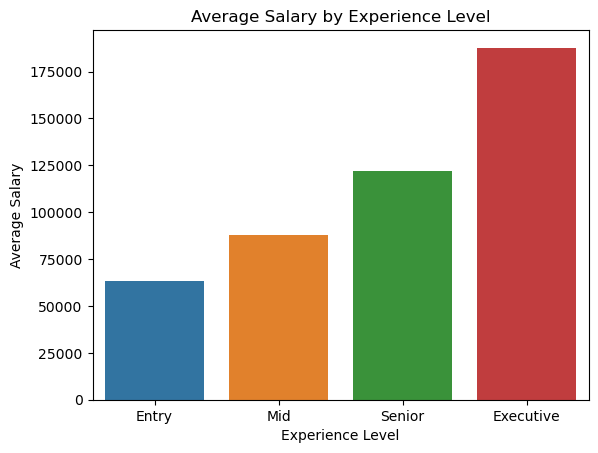

In [105]:
experience = df.copy()

experience['experience_level'] = experience['experience_level'].replace({
    'EN':'Entry',
    'MI':'Mid',
    'SE':'Senior',
    'EX':'Executive'
})

sns.barplot(x='experience_level', y='salary_usd', data=experience, estimator='mean',order=['Entry','Mid','Senior','Executive'],errorbar = None)
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.show()

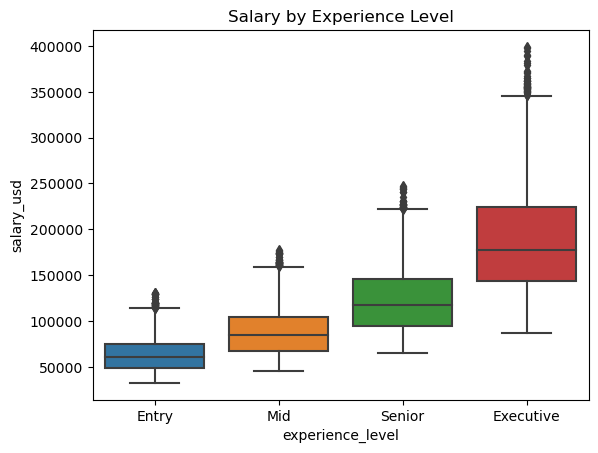

In [104]:
plt.title('Salary by Experience Level')
sns.boxplot(data=experience,x='experience_level',y='salary_usd',order=['Entry','Mid','Senior','Executive'])
plt.show()

### Job Openings by Experience Level

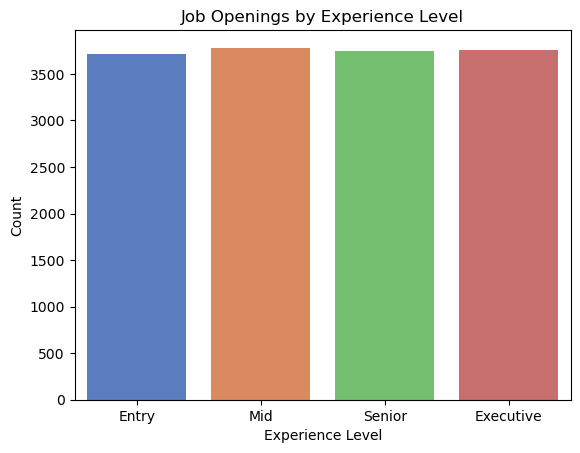

In [120]:
sns.countplot(data=experience, x='experience_level', palette='muted',order=['Entry','Mid','Senior','Executive'])
plt.title("Job Openings by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.show()

### Average Salary by Company Size

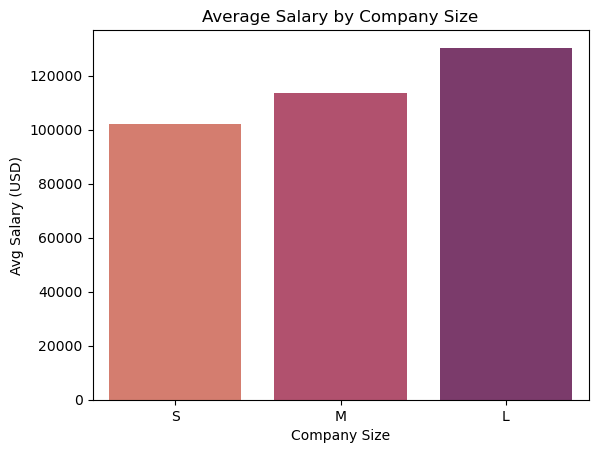

In [127]:
sns.barplot(data=df, x='company_size', y='salary_usd', palette='flare', order = ['S', 'M', 'L'], errorbar = None)
plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Avg Salary (USD)")
plt.show()


### Distribution of Employment Type

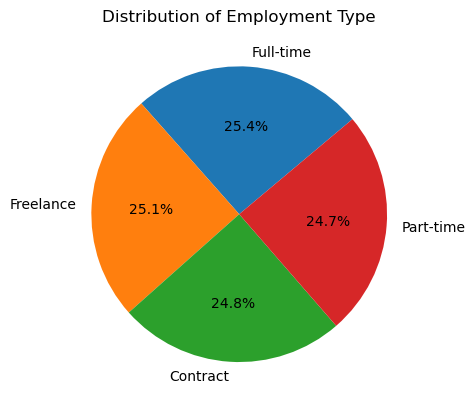

In [84]:
e_type = df['employment_type'].value_counts()

plt.title('Distribution of Employment Type')

plt.pie(e_type, labels=['Full-time','Freelance','Contract','Part-time'], autopct='%1.1f%%', startangle=40)

plt.show()

### Distribution of remote Type

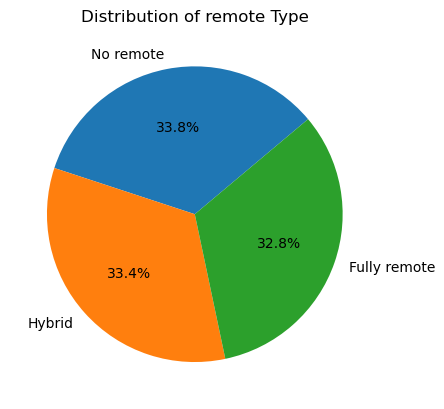

In [85]:
r_type = df['remote_ratio'].value_counts()

plt.title('Distribution of remote Type')

plt.pie(r_type, labels=['No remote','Hybrid','Fully remote'], autopct='%1.1f%%', startangle=40)

plt.show()

### Benefits score distribution

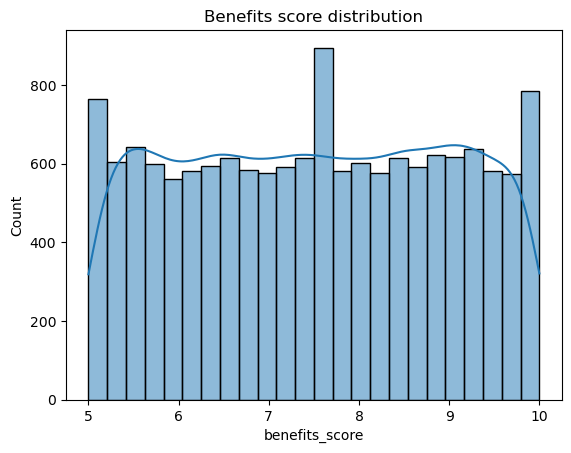

In [98]:
plt.title('Benefits score distribution')
sns.histplot(df['benefits_score'],kde=True)
plt.show()

### Job wise most required skills

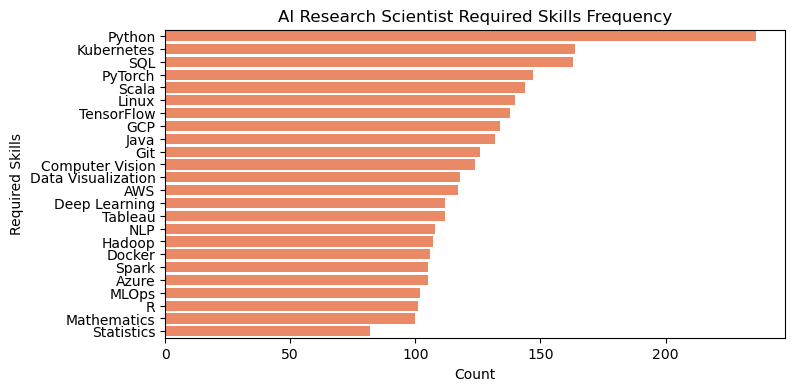

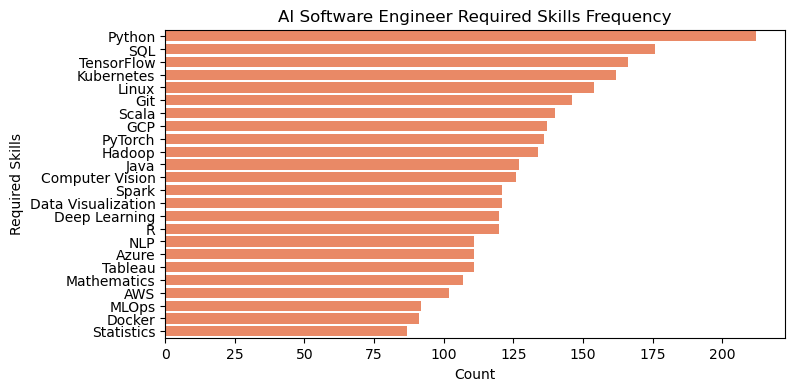

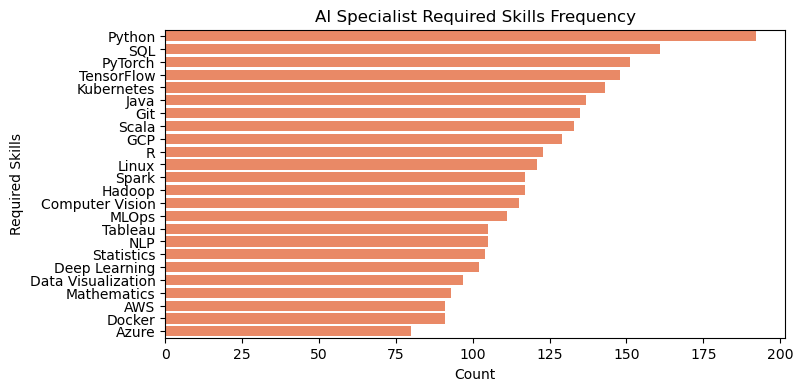

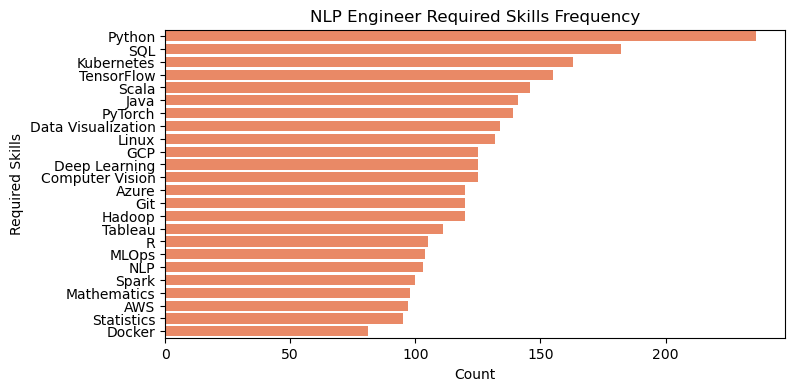

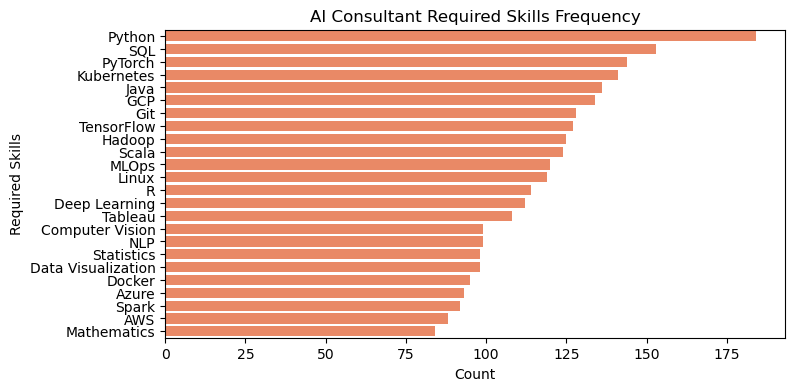

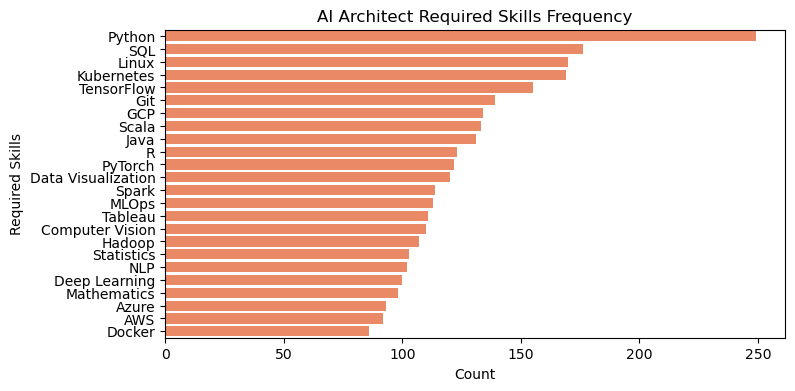

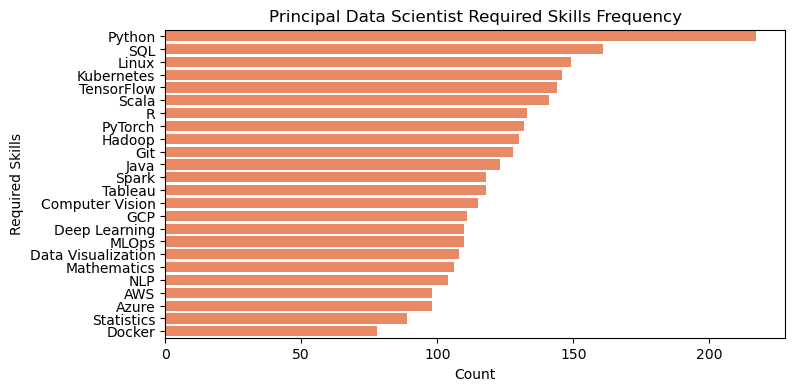

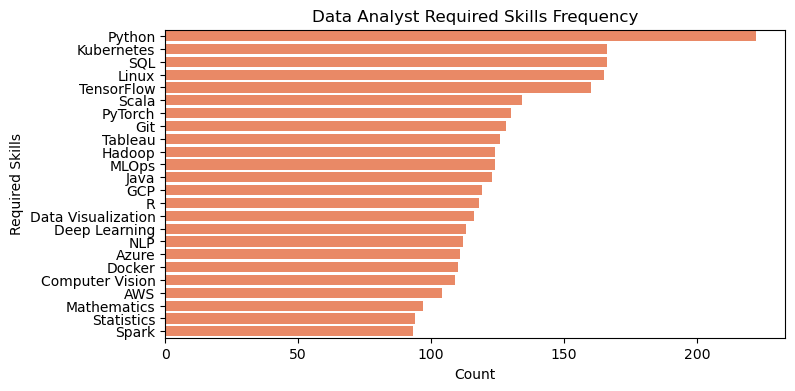

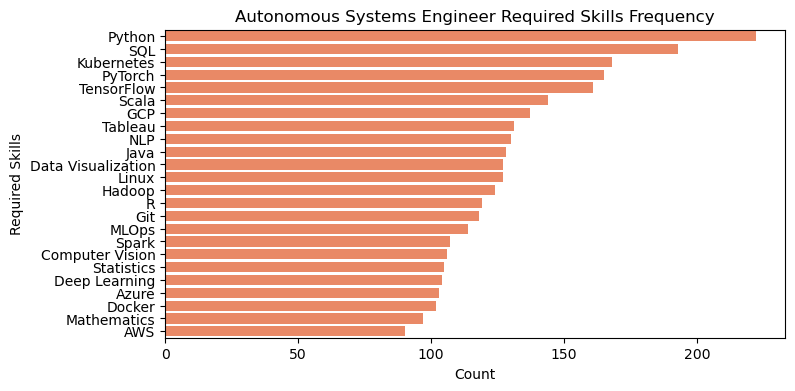

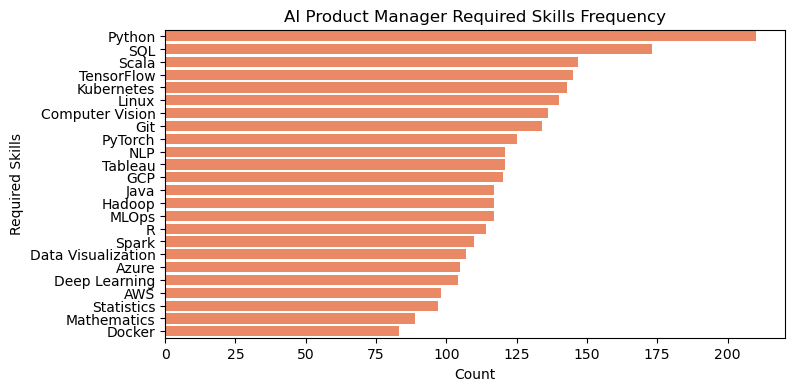

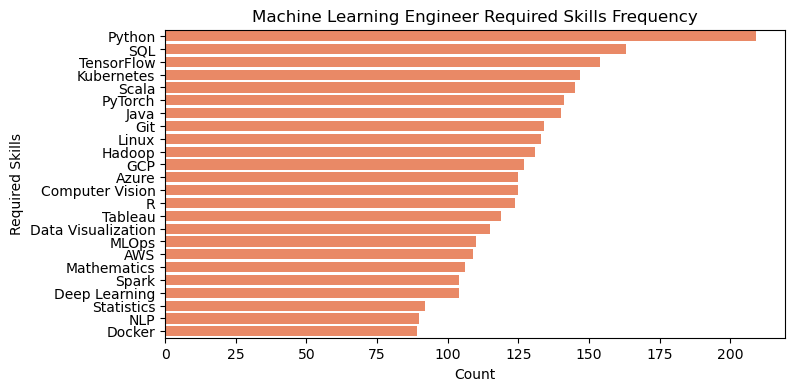

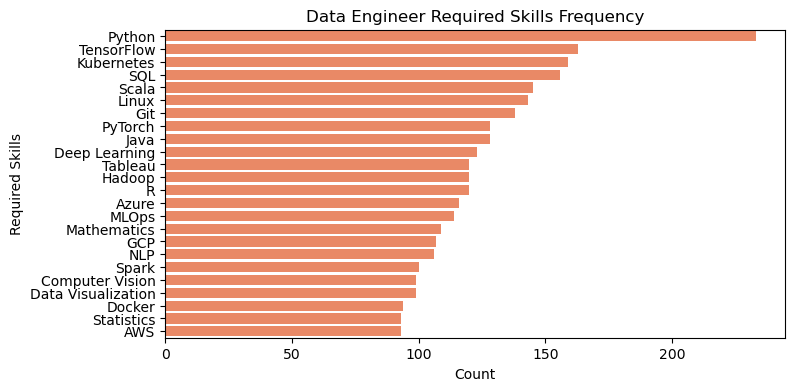

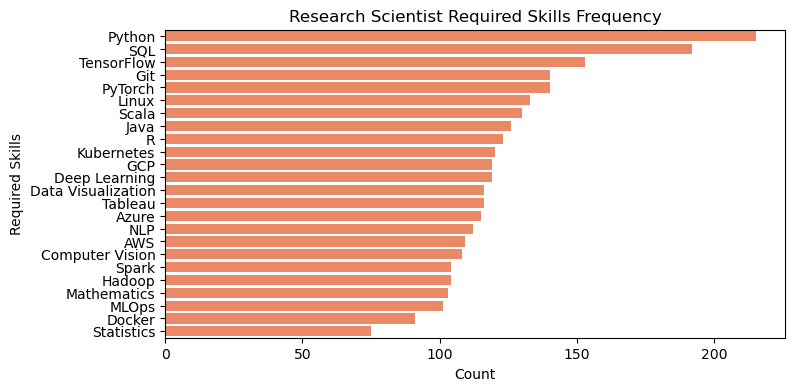

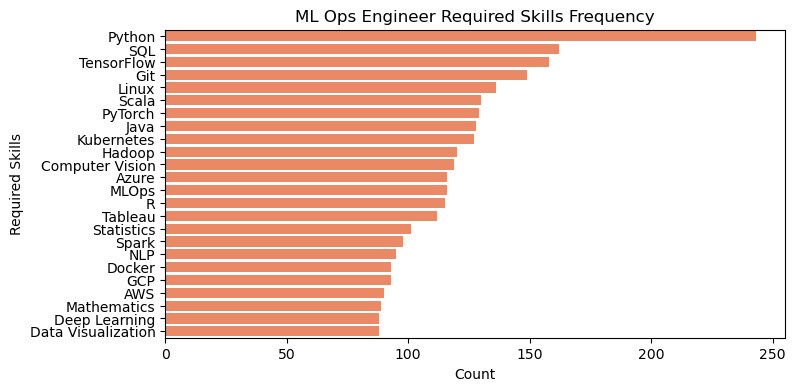

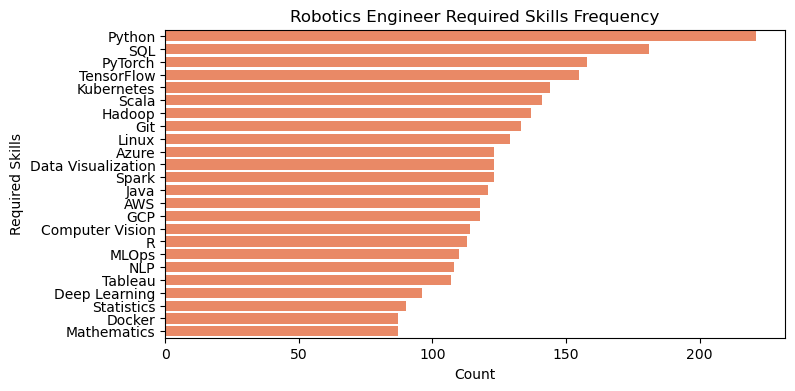

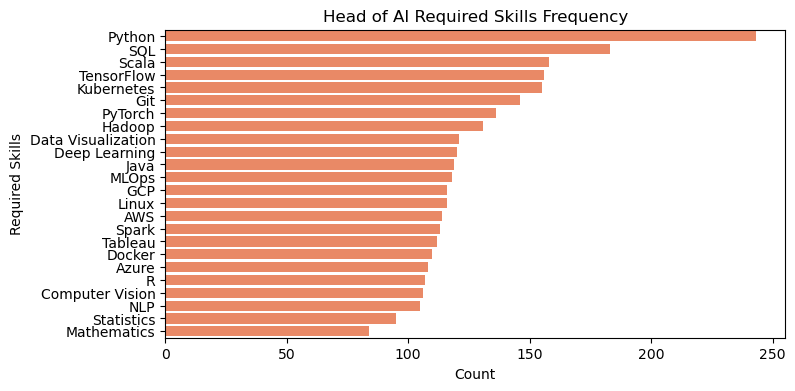

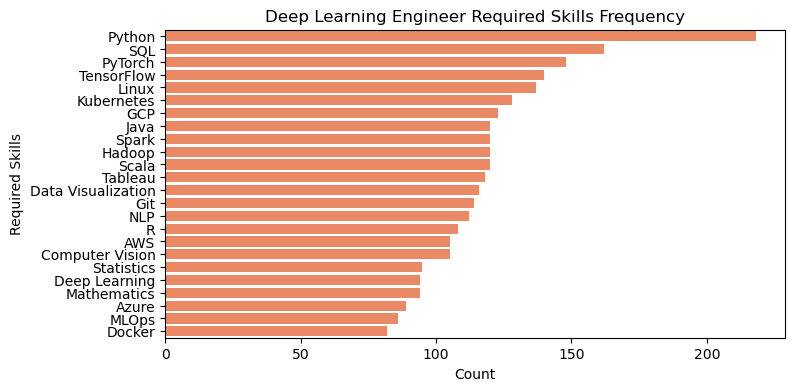

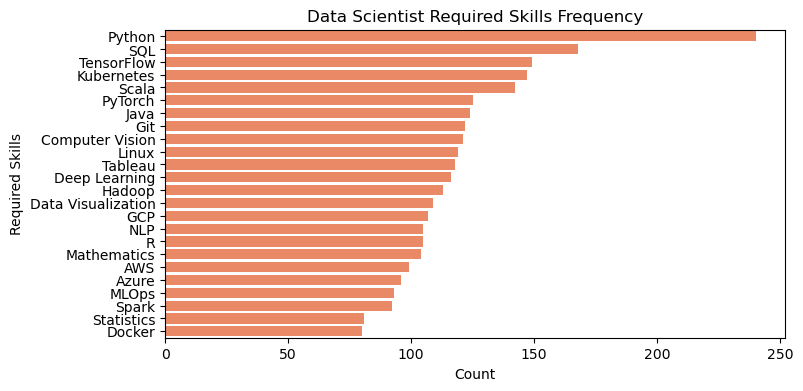

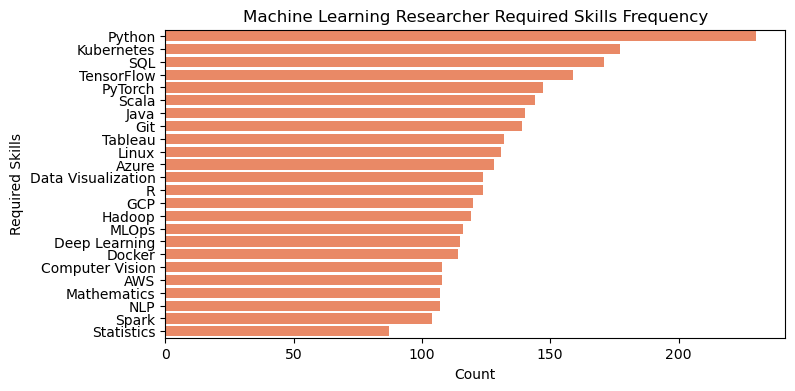

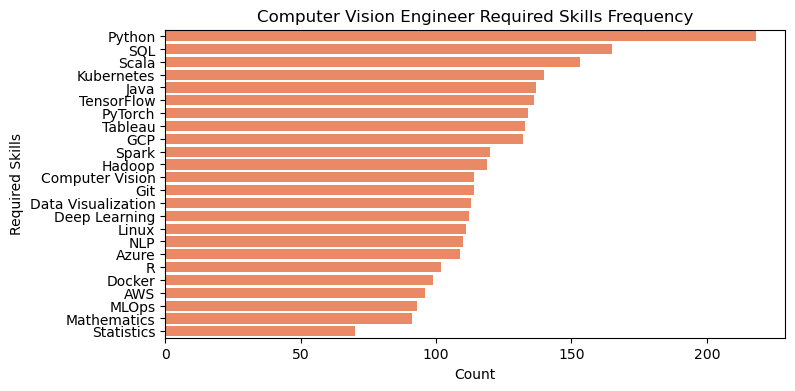

In [145]:
skill_data = df.copy()

skill_data['required_skills'] = skill_data['required_skills'].str.split(',')
skill_data = skill_data.explode('required_skills')
skill_data['required_skills'] = skill_data['required_skills'].str.strip()

unique_titles = skill_data['job_title'].unique()

for title in unique_titles:
    subset = skill_data[skill_data['job_title'] == title]
    order = subset['required_skills'].value_counts().index
    
    plt.figure(figsize=(8, 4))
    sns.countplot(data=subset, y='required_skills', color='coral', order=order)
    plt.title(f"{title} Required Skills Frequency")
    plt.xlabel("Count")
    plt.ylabel("Required Skills")
    plt.show()